In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
# Plot style
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

In [3]:
# import data
df = pd.read_csv('data_ANN.csv')

In [4]:
# df = pd.DataFrame(data)

print("=== Dataset Overview ===")
print(df.head())
print(f"\nShape: {df.shape}")
print("\nStatistics:")
print(df.describe())

=== Dataset Overview ===
   No.  phi  Ha       Ra       Nu
0    1  0.0   0     1000   7.7476
1    2  0.0   0    10000   7.7555
2    3  0.0   0   100000   8.8559
3    4  0.0   0  1000000  13.4330
4    5  0.0  20     1000   7.7475

Shape: (144, 5)

Statistics:
              No.         phi          Ha              Ra          Nu
count  144.000000  144.000000  144.000000      144.000000  144.000000
mean    72.500000    0.025000   50.000000   277750.000000    9.288892
std     41.713307    0.017138   34.275723   420245.907033    1.736707
min      1.000000    0.000000    0.000000     1000.000000    7.747500
25%     36.750000    0.010000   20.000000     7750.000000    8.200300
50%     72.500000    0.025000   50.000000    55000.000000    8.671090
75%    108.250000    0.040000   80.000000   325000.000000    9.518155
max    144.000000    0.050000  100.000000  1000000.000000   14.408424


In [5]:
X = df[['phi', 'Ha', 'Ra']]
y = df['Nu']

In [6]:
# Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
print(f"\nTraining samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")


Training samples : 115
Testing samples  : 29


In [8]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

In [9]:
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred_train = rf_model.predict(X_train)
y_pred_test  = rf_model.predict(X_test)
# Full dataset predictions (for comparison graphs)
y_pred_all = rf_model.predict(X)

In [11]:
def evaluate(y_true, y_pred, label):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"\n--- {label} ---")
    print(f"  R²   : {r2:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    return r2, rmse, mae, mape

print("\n=== Evaluation Metrics ===")
r2_tr, rmse_tr, mae_tr, mape_tr = evaluate(y_train, y_pred_train, "Training Set")
r2_te, rmse_te, mae_te, mape_te = evaluate(y_test,  y_pred_test,  "Test Set")


=== Evaluation Metrics ===

--- Training Set ---
  R²   : 0.9991
  RMSE : 0.0516
  MAE  : 0.0297
  MAPE : 0.30%

--- Test Set ---
  R²   : 0.9962
  RMSE : 0.1058
  MAE  : 0.0626
  MAPE : 0.62%


In [14]:
train_sizes, train_scores, val_scores = learning_curve(
    rf_model, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='r2',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

train_rmse_scores = np.sqrt(-cross_val_score(
    rf_model, X, y, cv=5, scoring='neg_mean_squared_error'))

print("Learning Curve")
print(f"  Final Train R²      : {train_mean[-1]:.4f} ± {train_std[-1]:.4f}")
print(f"  Final Validation R² : {val_mean[-1]:.4f}  ± {val_std[-1]:.4f}")
print(f"  CV RMSE             : {train_rmse_scores.mean():.4f} ± {train_rmse_scores.std():.4f}")


Learning Curve
  Final Train R²      : 0.9991 ± 0.0001
  Final Validation R² : 0.9889  ± 0.0067
  CV RMSE             : 0.1670 ± 0.0558


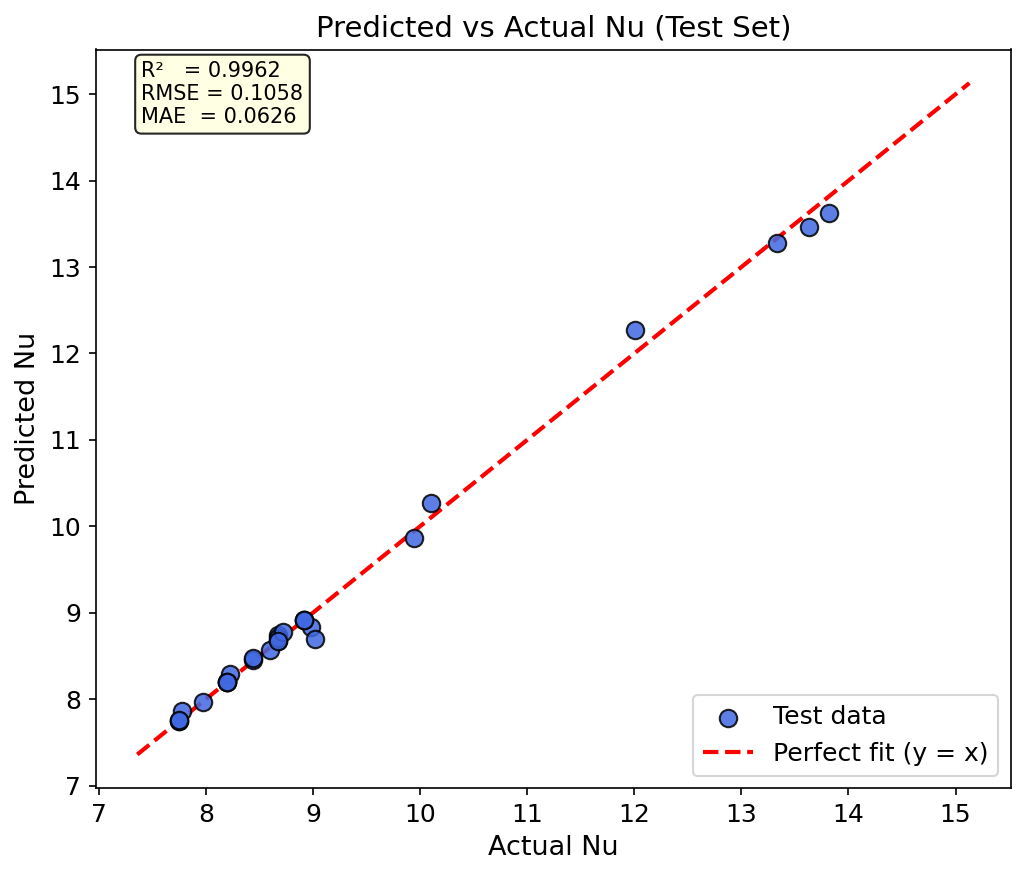

In [15]:
# Graph 1: Predicted vs Actual — Test Set
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_test, color='royalblue', edgecolors='k',
           alpha=0.85, s=70, label='Test data', zorder=3)
lims = [min(y.min(), y_pred_test.min()) * 0.95,
        max(y.max(), y_pred_test.max()) * 1.05]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect fit (y = x)')
ax.set_xlabel('Actual Nu', fontsize=13)
ax.set_ylabel('Predicted Nu', fontsize=13)
ax.set_title('Predicted vs Actual Nu (Test Set)', fontsize=14)
ax.legend()
ax.text(0.05, 0.90, f'R²   = {r2_te:.4f}\nRMSE = {rmse_te:.4f}\nMAE  = {mae_te:.4f}',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))
plt.tight_layout()
#plt.savefig('graph1_predicted_vs_actual.png', dpi=200)
plt.show()
#print("Saved: graph1_predicted_vs_actual.png")

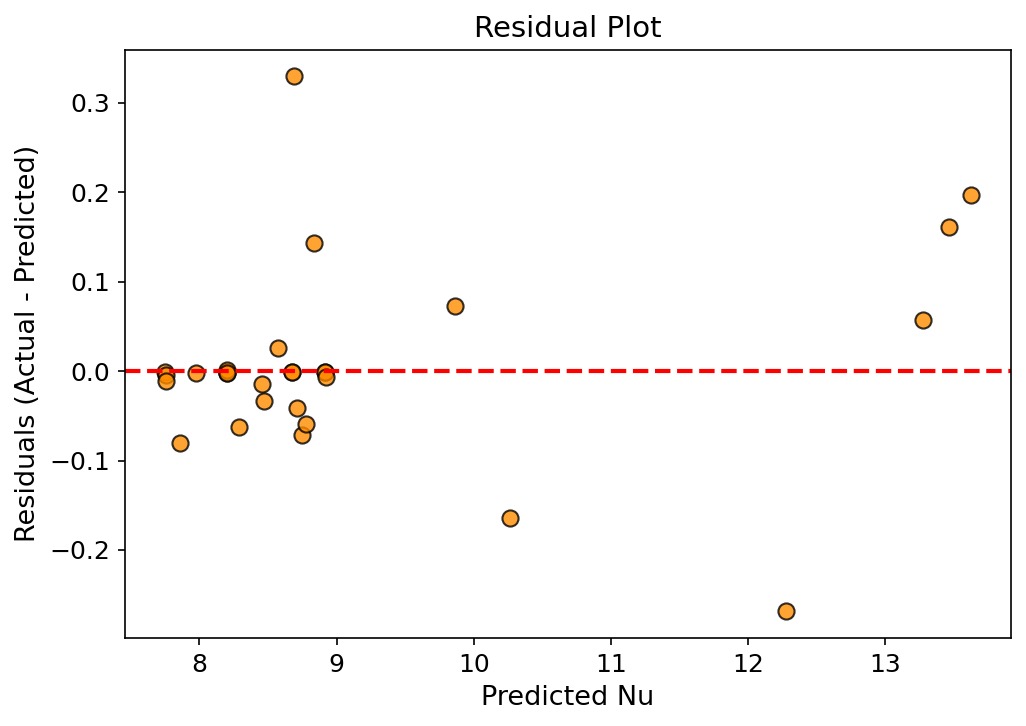

In [16]:
#  Graph 2: Residual Plot 
residuals = y_test - y_pred_test
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_pred_test, residuals, color='darkorange', edgecolors='k', alpha=0.8, s=60)
ax.axhline(0, color='red', linestyle='--', lw=2)
ax.set_xlabel('Predicted Nu', fontsize=13)
ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=13)
ax.set_title('Residual Plot', fontsize=14)
plt.tight_layout()
# plt.savefig('graph2_residuals.png', dpi=200)
plt.show()
# print("Saved: graph2_residuals.png")


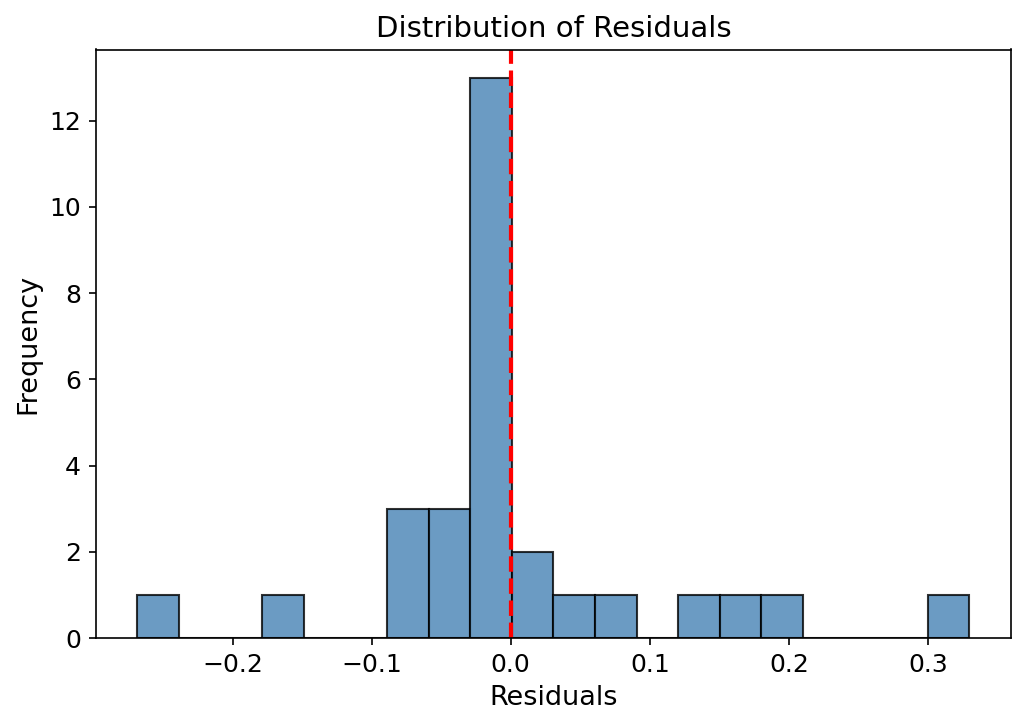

In [17]:
# Graph 3: Residual Distribution Histogram
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(residuals, bins=20, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', lw=2)
ax.set_xlabel('Residuals', fontsize=13)
ax.set_ylabel('Frequency', fontsize=13)
ax.set_title('Distribution of Residuals', fontsize=14)
plt.tight_layout()
# plt.savefig('graph3_residual_histogram.png', dpi=200)
plt.show()
# print("Saved: graph3_residual_histogram.png")

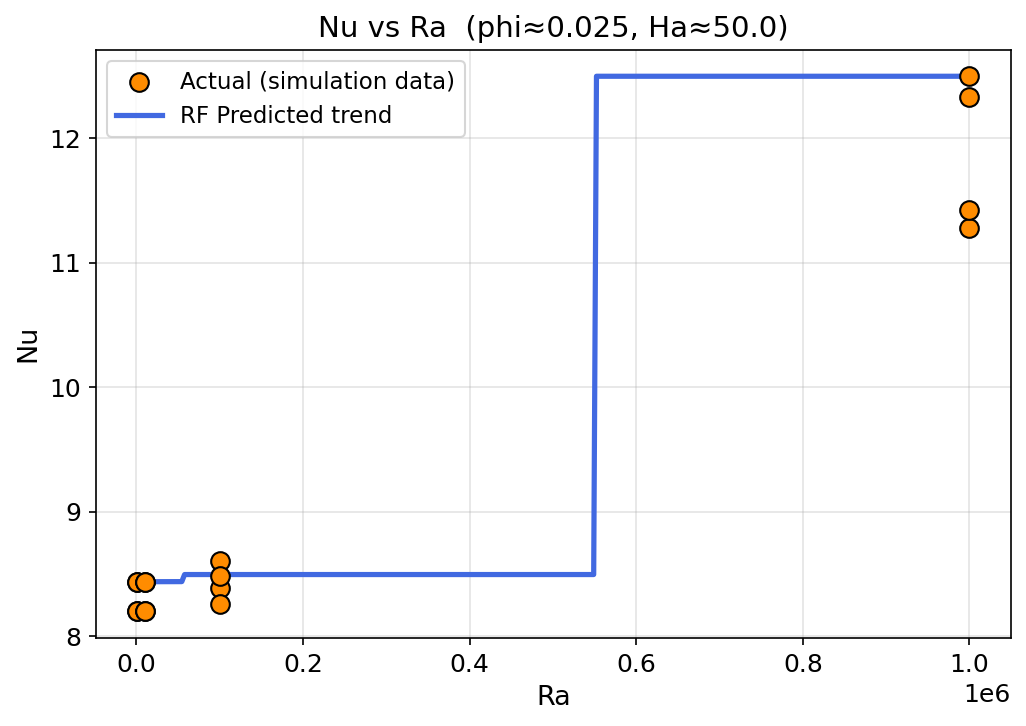

In [18]:
# Graph 5: Nu vs Ra (Physical Trend Check)
# Fix phi and Ha at their median, vary Ra
phi_fixed = df['phi'].median()
Ha_fixed  = df['Ha'].median()
Ra_fixed  = df['Ra'].median()

# Filter actual data near fixed phi and Ha values
tol_phi = (df['phi'].max() - df['phi'].min()) * 0.15
tol_Ha  = (df['Ha'].max()  - df['Ha'].min())  * 0.15 + 1e-9  # +epsilon if Ha=0

mask_Ra = (np.abs(df['phi'] - phi_fixed) <= tol_phi) & \
          (np.abs(df['Ha']  - Ha_fixed)  <= tol_Ha)
df_Ra_actual = df[mask_Ra].sort_values('Ra')

# Predicted curve
Ra_range  = np.linspace(df['Ra'].min(), df['Ra'].max(), 300)
X_trend   = pd.DataFrame({'phi': phi_fixed, 'Ha': Ha_fixed, 'Ra': Ra_range})
Nu_pred_Ra = rf_model.predict(X_trend)

fig, ax = plt.subplots(figsize=(7, 5))
if len(df_Ra_actual) > 0:
    ax.scatter(df_Ra_actual['Ra'], df_Ra_actual['Nu'],
               color='darkorange', edgecolors='k', s=80, zorder=5,
               label='Actual (simulation data)')
ax.plot(Ra_range, Nu_pred_Ra, color='royalblue', lw=2.5, label='RF Predicted trend')
ax.set_xlabel('Ra', fontsize=13)
ax.set_ylabel('Nu', fontsize=13)
ax.set_title(f'Nu vs Ra  (phi≈{phi_fixed}, Ha≈{Ha_fixed})', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.35)
plt.tight_layout()
#plt.savefig('graph5_Nu_vs_Ra.png', dpi=200)
plt.show()
#print("Saved: graph5_Nu_vs_Ra.png")

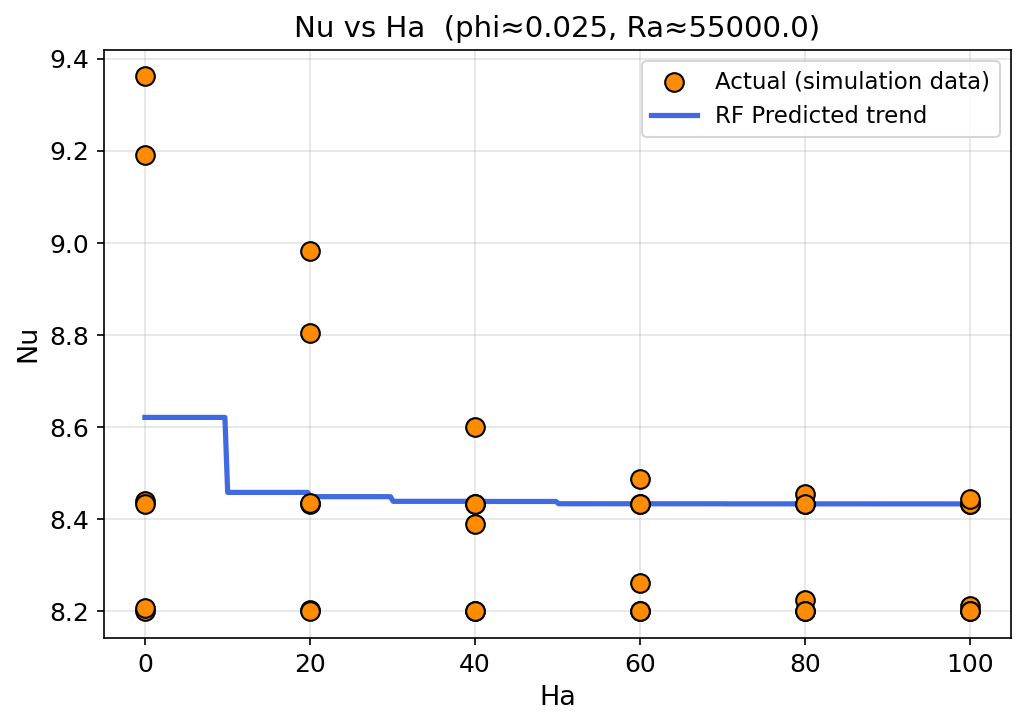

In [19]:
# Graph 6: Nu vs Ha (Physical Trend Check)
tol_Ra = (df['Ra'].max() - df['Ra'].min()) * 0.15

mask_Ha = (np.abs(df['phi'] - phi_fixed) <= tol_phi) & \
          (np.abs(df['Ra']  - Ra_fixed)  <= tol_Ra)
df_Ha_actual = df[mask_Ha].sort_values('Ha')

Ha_range   = np.linspace(df['Ha'].min(), df['Ha'].max(), 300)
X_trend2   = pd.DataFrame({'phi': phi_fixed, 'Ha': Ha_range, 'Ra': Ra_fixed})
Nu_pred_Ha = rf_model.predict(X_trend2)

fig, ax = plt.subplots(figsize=(7, 5))
if len(df_Ha_actual) > 0:
    ax.scatter(df_Ha_actual['Ha'], df_Ha_actual['Nu'],
               color='darkorange', edgecolors='k', s=80, zorder=5,
               label='Actual (simulation data)')
ax.plot(Ha_range, Nu_pred_Ha, color='royalblue', lw=2.5, label='RF Predicted trend')
ax.set_xlabel('Ha', fontsize=13)
ax.set_ylabel('Nu', fontsize=13)
ax.set_title(f'Nu vs Ha  (phi≈{phi_fixed}, Ra≈{Ra_fixed})', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.35)
plt.tight_layout()
#plt.savefig('graph6_Nu_vs_Ha.png', dpi=200)
plt.show()
#print("Saved: graph6_Nu_vs_Ha.png")

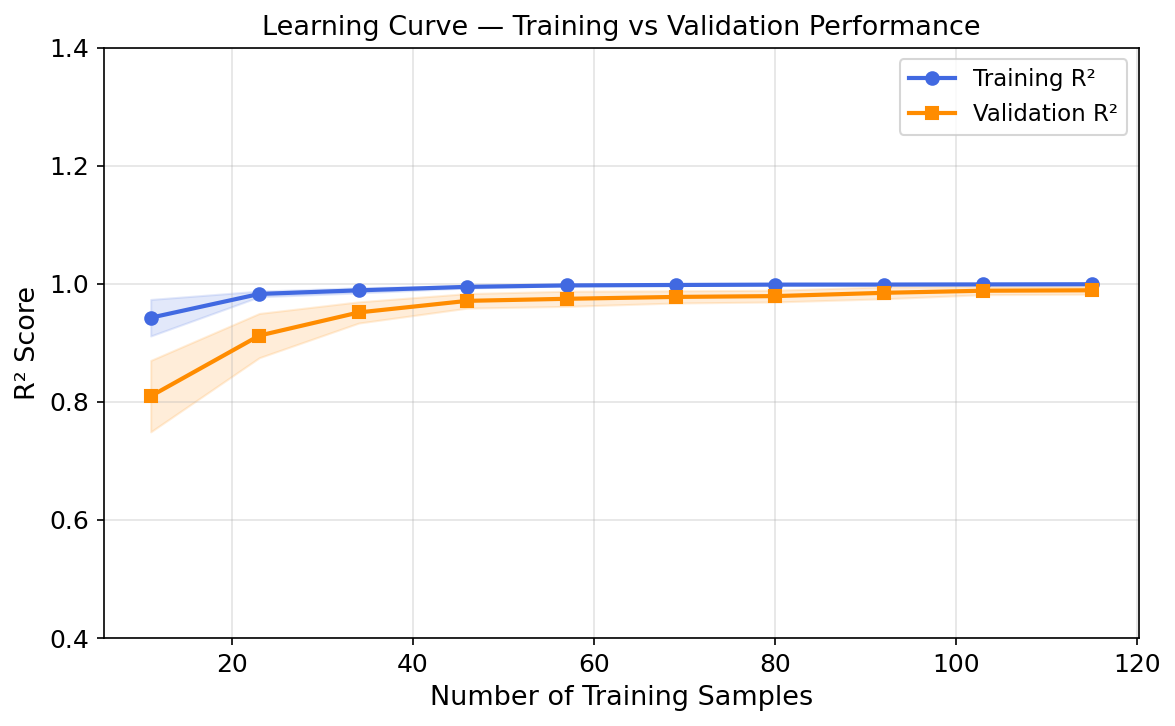

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, 'o-', color='royalblue', lw=2, label='Training R²')
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color='royalblue')
ax.plot(train_sizes, val_mean, 's-', color='darkorange', lw=2, label='Validation R²')
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color='darkorange')
ax.set_xlabel('Number of Training Samples', fontsize=13)
ax.set_ylabel('R² Score', fontsize=13)
ax.set_title('Learning Curve — Training vs Validation Performance', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0.4, 1.4)
ax.grid(True, alpha=0.35)
plt.tight_layout()
#plt.savefig('graph7_learning_curve.png', dpi=200)
plt.show()
#print("Saved: graph7_learning_curve.png")


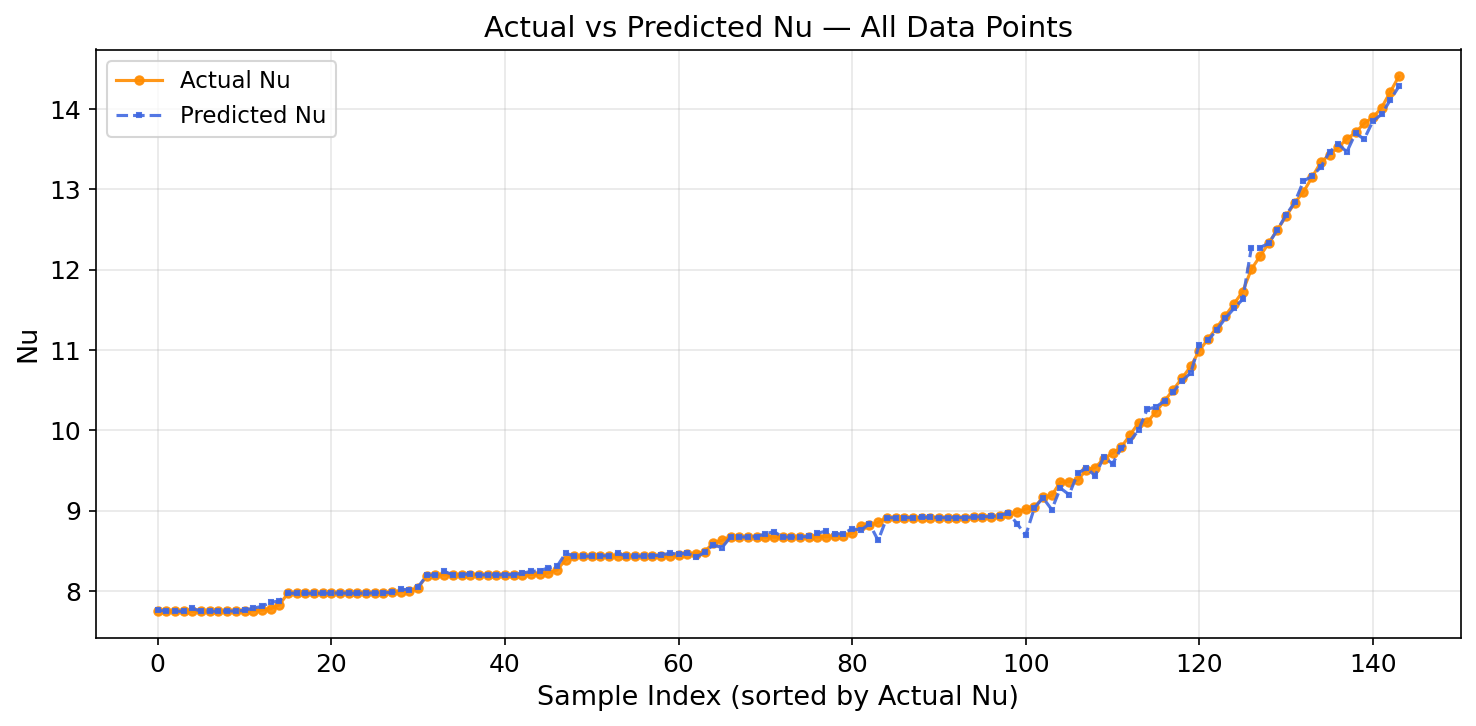

In [21]:
sample_idx = np.arange(len(y))
order      = np.argsort(y.values)   # Sort by actual Nu for cleaner view

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sample_idx, y.values[order],       'o-', color='darkorange', lw=1.5,
        markersize=4, label='Actual Nu',    alpha=0.9)
ax.plot(sample_idx, y_pred_all[order],     's--', color='royalblue', lw=1.5,
        markersize=2, label='Predicted Nu', alpha=0.9)
ax.set_xlabel('Sample Index (sorted by Actual Nu)', fontsize=13)
ax.set_ylabel('Nu', fontsize=13)
ax.set_title('Actual vs Predicted Nu — All Data Points', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('graph8_actual_vs_predicted_index.png', dpi=200)
plt.show()
#print("Saved: graph8_actual_vs_predicted_index.png")

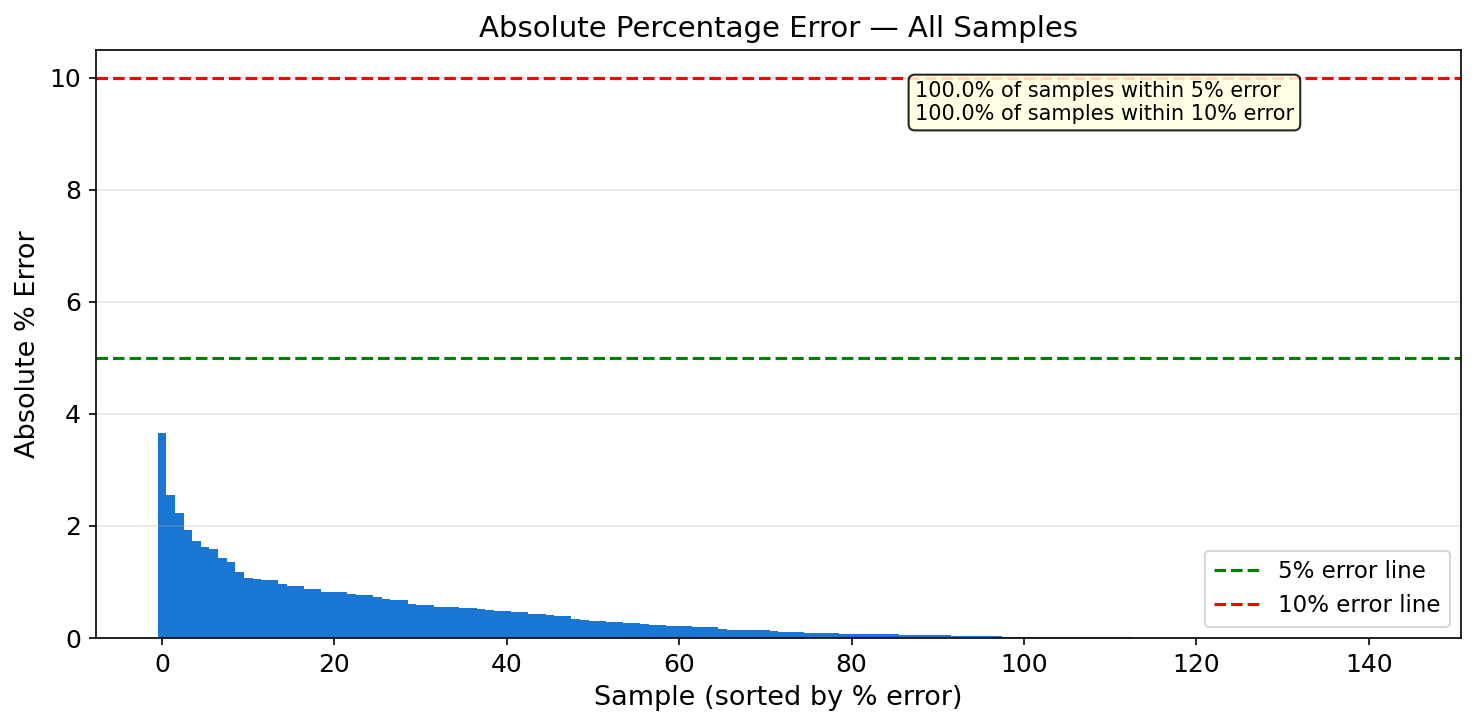

Saved: graph9_percentage_error.png


In [22]:

# Graph 9: Percentage Error per Sample (full dataset)

pct_error = np.abs((y.values - y_pred_all) / y.values) * 100
order2    = np.argsort(pct_error)[::-1]   # Sort worst to best

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#d32f2f' if e > 10 else '#1976d2' for e in pct_error[order2]]
ax.bar(np.arange(len(pct_error)), pct_error[order2], color=bar_colors,
       edgecolor='none', width=1.0)
ax.axhline(5,  color='green',  linestyle='--', lw=1.5, label='5% error line')
ax.axhline(10, color='red',    linestyle='--', lw=1.5, label='10% error line')
ax.set_xlabel('Sample (sorted by % error)', fontsize=13)
ax.set_ylabel('Absolute % Error', fontsize=13)
ax.set_title('Absolute Percentage Error — All Samples', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
# Annotation: % of samples within 5% and 10%
within_5  = np.sum(pct_error <= 5)  / len(pct_error) * 100
within_10 = np.sum(pct_error <= 10) / len(pct_error) * 100
ax.text(0.60, 0.88,
        f'{within_5:.1f}% of samples within 5% error\n'
        f'{within_10:.1f}% of samples within 10% error',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))
plt.tight_layout()
plt.savefig('graph9_percentage_error.png', dpi=200)
plt.show()
print("Saved: graph9_percentage_error.png")

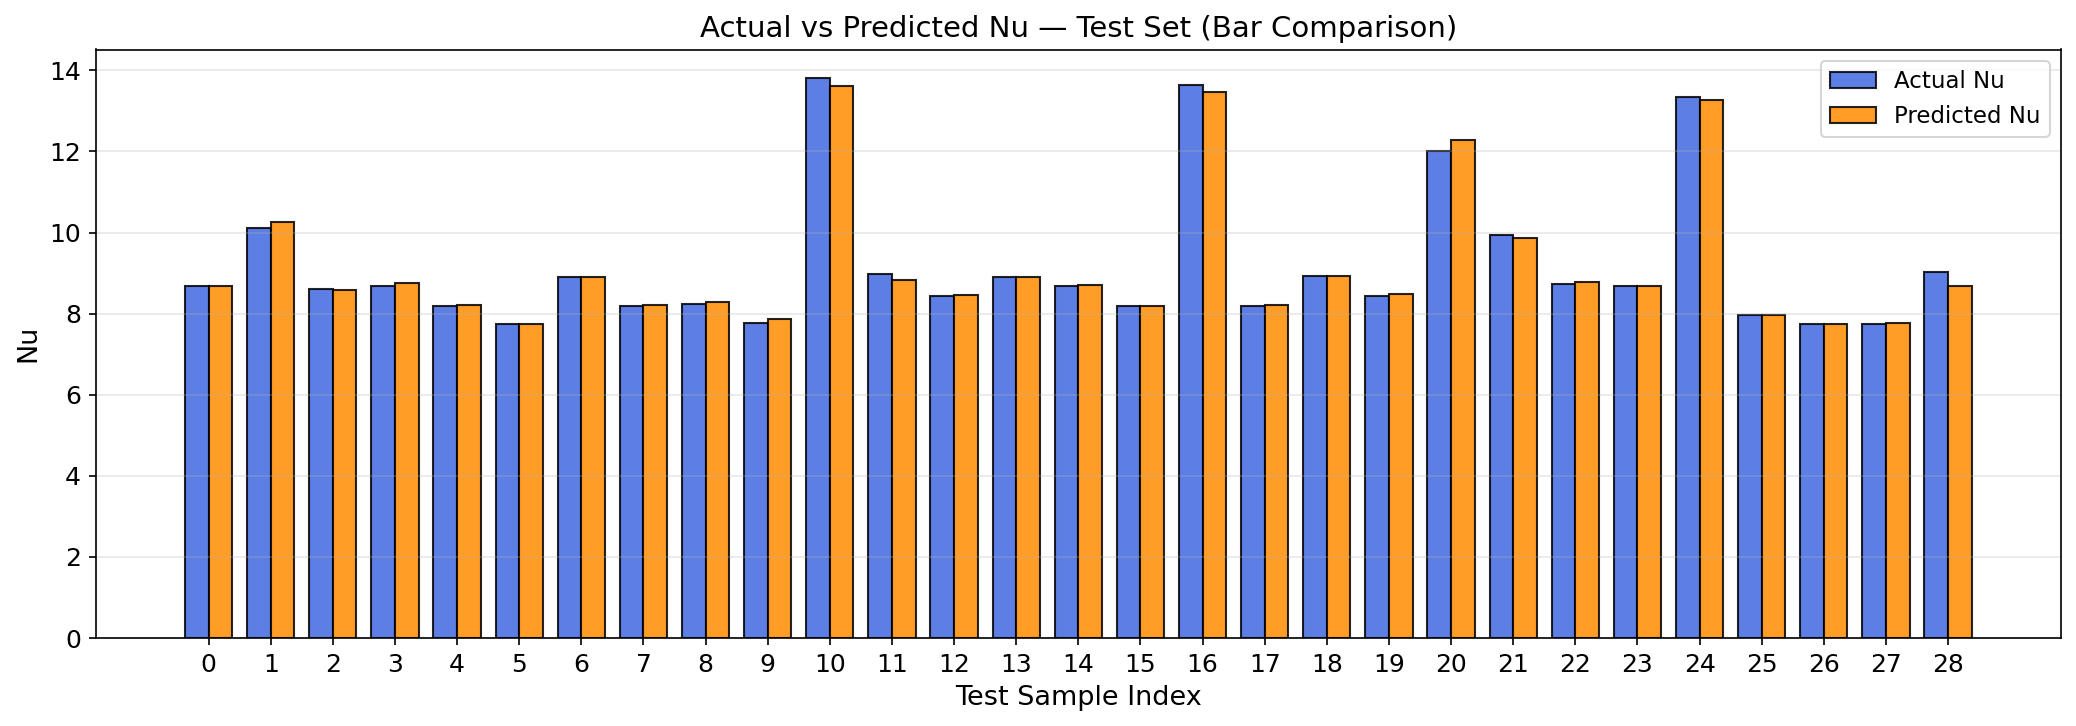

In [33]:

# Graph 10: Side-by-Side Bar Chart — Actual vs Predicted (Test Set only)

test_indices  = np.arange(len(y_test))
actual_vals   = y_test.values
predicted_vals = y_pred_test
bar_width     = 0.38

fig, ax = plt.subplots(figsize=(max(10, len(y_test)//2), 5))
ax.bar(test_indices - bar_width/2, actual_vals,    bar_width,
       label='Actual Nu',    color='royalblue', edgecolor='k', alpha=0.85)
ax.bar(test_indices + bar_width/2, predicted_vals, bar_width,
       label='Predicted Nu', color='darkorange',  edgecolor='k', alpha=0.85)
ax.set_xlabel('Test Sample Index', fontsize=13)
ax.set_ylabel('Nu', fontsize=13)
ax.set_title('Actual vs Predicted Nu — Test Set (Bar Comparison)', fontsize=14)
ax.legend(fontsize=11)
ax.set_xticks(test_indices)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
#plt.savefig('graph10_bar_comparison_test.png', dpi=200)
plt.show()
#print("Saved: graph10_bar_comparison_test.png")


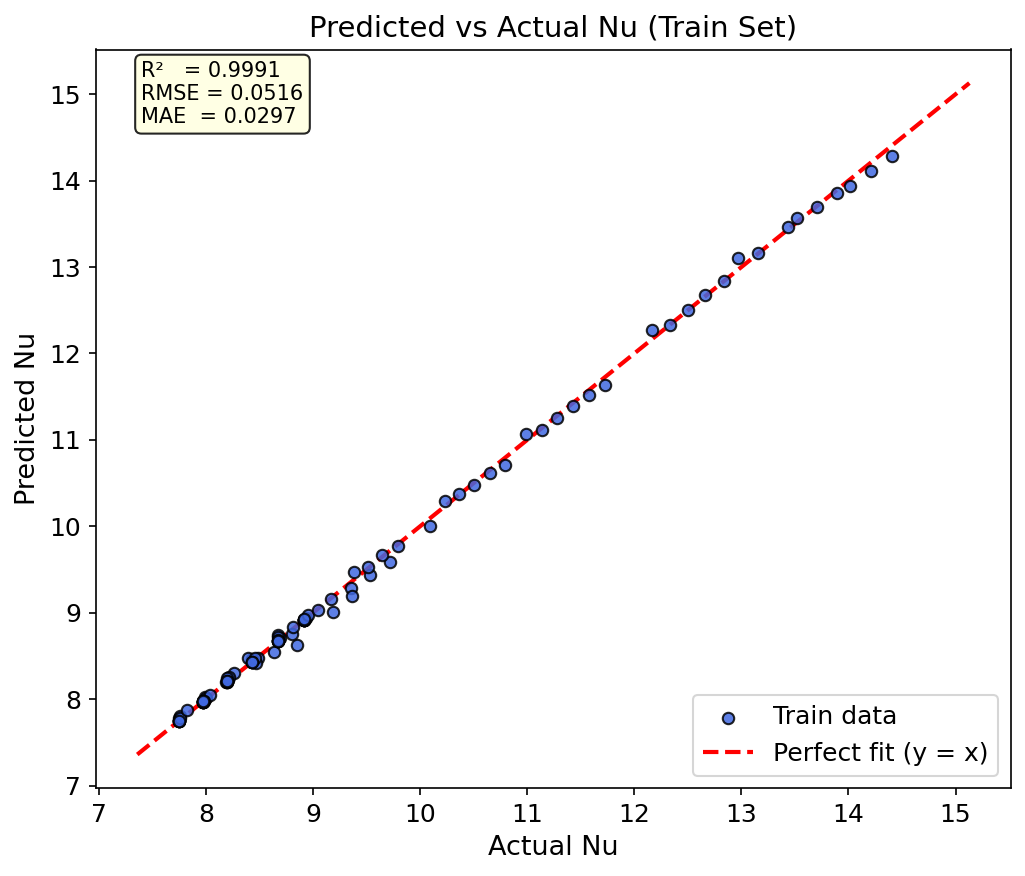

In [28]:
# Predicted vs Actual — Test Set
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_train, y_pred_train, color='royalblue', edgecolors='k',
           alpha=0.85, s=30, label='Train data', zorder=3)
lims = [min(y.min(), y_pred_train.min()) * 0.95,
        max(y.max(), y_pred_train.max()) * 1.05]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect fit (y = x)')
ax.set_xlabel('Actual Nu', fontsize=13)
ax.set_ylabel('Predicted Nu', fontsize=13)
ax.set_title('Predicted vs Actual Nu (Train Set)', fontsize=14)
ax.legend()
ax.text(0.05, 0.90, f'R²   = {r2_tr:.4f}\nRMSE = {rmse_tr:.4f}\nMAE  = {mae_tr:.4f}',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))
plt.tight_layout()
#plt.savefig('graph1_predicted_vs_actual.png', dpi=200)
plt.show()
#print("Saved: graph1_predicted_vs_actual.png")


φ = 0.01, Ha = 60
  Ra          : [1000, 10000, 100000, 1000000]
  Actual Nu   : [7.9717, 7.9722, 8.0421, 11.136]
  Predicted Nu: [7.9717, 7.9725, 8.051, 11.119]

φ = 0.05, Ha = 60
  Ra          : [1000, 10000, 100000, 1000000]
  Actual Nu   : [8.9135, 8.9138, 8.9563, 11.7284]
  Predicted Nu: [8.9141, 8.9146, 8.9739, 11.6318]


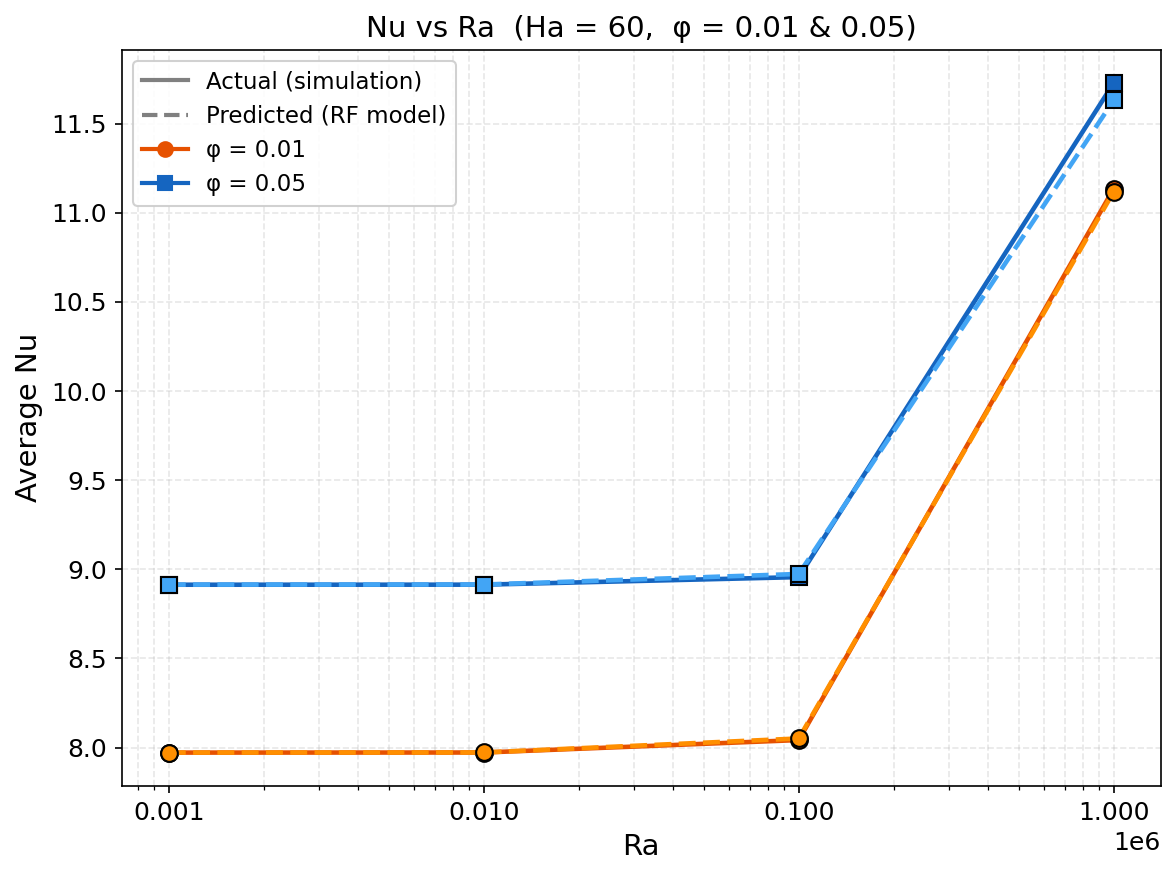

In [31]:

Ha_fixed  = 60
Ra_values = [1000, 10000, 100000, 1000000]
phi_list  = [0.01, 0.05]

colors_actual    = ['#E65100', '#1565C0']
colors_predicted = ['#FF8F00', '#42A5F5']

markers = ['o', 's']


# Compute average Nu (actual) and predicted Nu for each Ra, per phi

fig, ax = plt.subplots(figsize=(8, 6))

for i, phi_val in enumerate(phi_list):

    actual_avg_Nu    = []
    predicted_avg_Nu = []

    for Ra_val in Ra_values:
        # --- Actual: filter rows matching this phi, Ha, Ra ---
        mask = (
            (df['phi'] == phi_val) &
            (df['Ha']  == Ha_fixed) &
            (df['Ra']  == Ra_val)
        )
        subset = df[mask]

        if len(subset) > 0:
            actual_avg_Nu.append(subset['Nu'].mean())
        else:
            # If exact match not found, use nearest neighbours (tolerance-based)
            tol_phi = 1e-6
            tol_Ha  = 1e-6
            tol_Ra  = Ra_val * 0.01
            mask_tol = (
                (np.abs(df['phi'] - phi_val) <= tol_phi) &
                (np.abs(df['Ha']  - Ha_fixed) <= tol_Ha) &
                (np.abs(df['Ra']  - Ra_val)   <= tol_Ra)
            )
            subset_tol = df[mask_tol]
            if len(subset_tol) > 0:
                actual_avg_Nu.append(subset_tol['Nu'].mean())
            else:
                actual_avg_Nu.append(np.nan)
                print(f"  WARNING: No actual data found for phi={phi_val}, Ha={Ha_fixed}, Ra={Ra_val}")

        # --- Predicted ---
        X_pred = pd.DataFrame({
            'phi': [phi_val],
            'Ha':  [Ha_fixed],
            'Ra':  [Ra_val]
        })
        predicted_avg_Nu.append(rf_model.predict(X_pred)[0])

    # --- Plot actual ---
    ax.plot(Ra_values, actual_avg_Nu,
            marker=markers[i], linestyle='-', lw=2.2,
            color=colors_actual[i], markersize=8, markeredgecolor='k',
            label=f'Actual     φ={phi_val}')

    # --- Plot predicted ---
    ax.plot(Ra_values, predicted_avg_Nu,
            marker=markers[i], linestyle='--', lw=2.2,
            color=colors_predicted[i], markersize=8, markeredgecolor='k',
            label=f'Predicted  φ={phi_val}')

    # Print values for verification
    print(f"\nφ = {phi_val}, Ha = {Ha_fixed}")
    print(f"  Ra          : {Ra_values}")
    print(f"  Actual Nu   : {[round(v, 4) if not np.isnan(v) else 'N/A' for v in actual_avg_Nu]}")
    print(f"  Predicted Nu: {[round(v, 4) for v in predicted_avg_Nu]}")


ax.set_xscale('log')
ax.set_xlabel('Ra', fontsize=14)
ax.set_ylabel('Average Nu', fontsize=14)
ax.set_title(f'Nu vs Ra  (Ha = {Ha_fixed},  φ = 0.01 & 0.05)', fontsize=14)

ax.set_xticks(Ra_values)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))

ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, which='both', alpha=0.3, linestyle='--')

# Solid line = Actual, Dashed = Predicted legend note
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='grey', lw=2,   linestyle='-',  label='Actual (simulation)'),
    Line2D([0], [0], color='grey', lw=2,   linestyle='--', label='Predicted (RF model)'),
    Line2D([0], [0], color=colors_actual[0],    lw=2, marker='o', markersize=7, label='φ = 0.01'),
    Line2D([0], [0], color=colors_actual[1],    lw=2, marker='s', markersize=7, label='φ = 0.05'),
]
ax.legend(handles=legend_handles, fontsize=11, framealpha=0.9)

plt.tight_layout()
# plt.savefig('graph_Nu_vs_Ra_line.png', dpi=200)
plt.show()
# print("\nSaved: graph_Nu_vs_Ra_line.png")
